In [1]:
# =============================================================
# Configuracion. Un solo generador aleatorio, con semilla fija,
# para que TODA la sesion sea reproducible.
# =============================================================
import numpy as np
import matplotlib.pyplot as plt          
from scipy import stats

SEED = 42
rng = np.random.default_rng(SEED)        

plt.rcParams["figure.figsize"] = (7, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

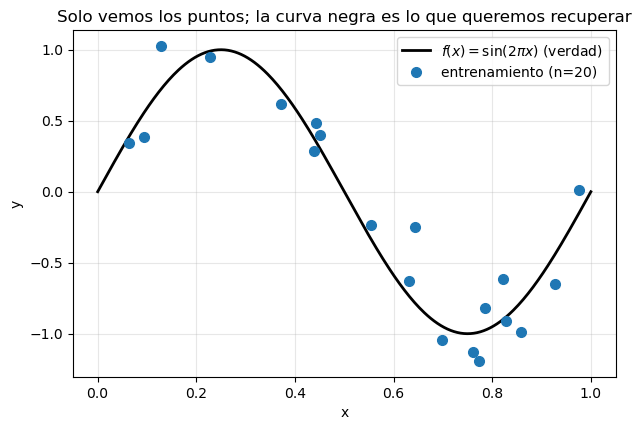

Error irreducible teorico: sigma^2 = 0.0625


In [2]:
# -------------------------------------------------------------
# Datos sinteticos: conocemos la verdad f(x) = sin(2 pi x)
# -------------------------------------------------------------
def f_verdadera(x):
    return np.sin(2*np.pi*x)

SIGMA = 0.25          # desviacion estandar del ruido -> error irreducible = SIGMA**2

def genera_datos(n, sigma=SIGMA, rng=rng):
    x = np.sort(rng.uniform(0, 1, n))
    y = f_verdadera(x) + rng.normal(0, sigma, n)
    return x, y

n_train = 20
x_tr, y_tr = genera_datos(n_train)
x_te, y_te = genera_datos(500)          # conjunto de prueba grande

xx = np.linspace(0, 1, 300)
plt.plot(xx, f_verdadera(xx), "k-", lw=2, label=r"$f(x)=\sin(2\pi x)$ (verdad)")
plt.plot(x_tr, y_tr, "o", ms=7, label=f"entrenamiento (n={n_train})")
plt.xlabel("x"); plt.ylabel("y"); plt.legend()
plt.title("Solo vemos los puntos; la curva negra es lo que queremos recuperar")
plt.show()

print(f"Error irreducible teorico: sigma^2 = {SIGMA**2:.4f}")

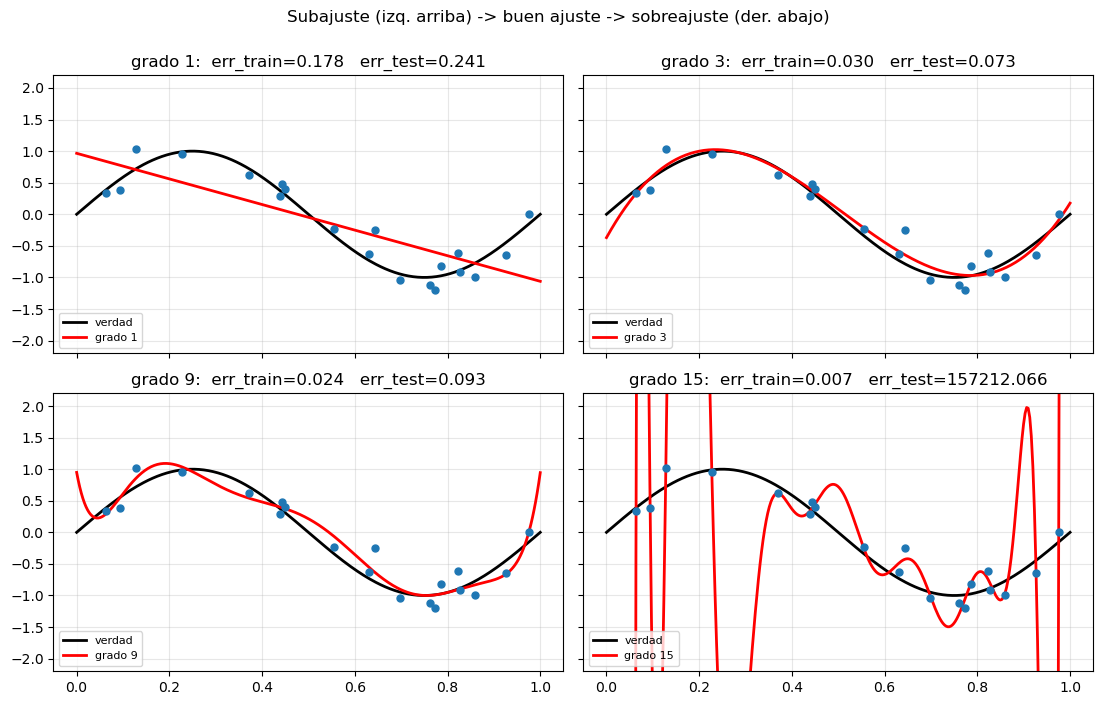

In [3]:
# -------------------------------------------------------------
# Ajuste polinomial para 4 grados distintos
# -------------------------------------------------------------
def ajusta_polinomio(x, y, grado):
    """Devuelve una funcion predictora ajustada por minimos cuadrados."""
    coef = np.polyfit(x, y, grado)
    return np.poly1d(coef)

def ecm(y_real, y_pred):
    return np.mean((y_real - y_pred)**2)

grados = [1, 3, 9, 15]
fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True, sharey=True)

for ax, g in zip(axes.ravel(), grados):
    modelo = ajusta_polinomio(x_tr, y_tr, g)
    e_tr = ecm(y_tr, modelo(x_tr))
    e_te = ecm(y_te, modelo(x_te))
    ax.plot(xx, f_verdadera(xx), "k-", lw=2, label="verdad")
    ax.plot(xx, modelo(xx), "r-", lw=2, label=f"grado {g}")
    ax.plot(x_tr, y_tr, "o", ms=5, color="tab:blue")
    ax.set_title(f"grado {g}:  err_train={e_tr:.3f}   err_test={e_te:.3f}")
    ax.set_ylim(-2.2, 2.2)
    ax.legend(fontsize=8, loc="lower left")

fig.suptitle("Subajuste (izq. arriba) -> buen ajuste -> sobreajuste (der. abajo)", y=1.00)
fig.tight_layout()
plt.show()